In [2]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library(DESeq2)
library("apeglm")
library(patchwork)
library(ggrastr)
library(circlize)

theme_set(
    theme_classic(base_size = 12)
)
source('./plot_data.R')

Warning message:
“package ‘DESeq2’ was built under R version 4.2.3”
Loading required package: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.2.3”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.2.1”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    exp

In [47]:
de_df<- read.table(file = "../data/13_mature_rna_splicing_DE_results.tsv", sep = '\t', header = T, row.names = 1)

In [48]:
iso_level<- de_df$feature_id %>% sort() %>% unique()

mcolors <- c("#5E8C61FF",
             "#FFC857FF",
             "#D0AF84", 
             "#ADB9A1",
             "#8CBDBC",
             "#F0A96B",
             "#068D9D",
             "#B44E3FFF")

names(mcolors) = iso_level

mcolors_withsig = c(mcolors, "gray")
names(mcolors_withsig)<- c(names(mcolors), "Not sig")

mcol <- c("#80b1d3", "#fb8072", "grey")
names(mcol) <- c("Down in MUT", "Up in MUT", "Not sig")


de_df$type = as.character(de_df$feature_id)
de_df[de_df$labels == 'Not sig', 'type'] = 'Not sig'
de_df$type<- factor(de_df$type, levels = c(iso_level, 'Not sig'))
de_df[de_df$padj<10e-15, 'padj'] = 10e-15

Warning message:
“Removed 860 rows containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“Removed 860 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


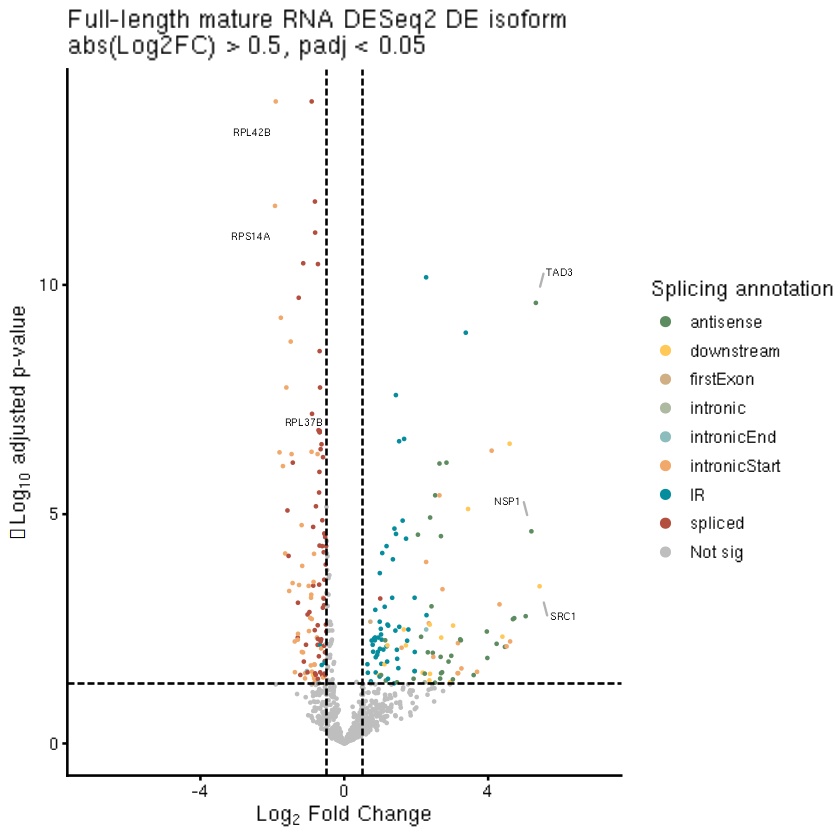

In [111]:
p <- de_df %>%
    ggplot(aes(x = log2FoldChange, y = -log10(padj), label = annotation)) +
    geom_point(aes(color = type), size = 0.2) +
    geom_text_repel(box.padding = 1, point.padding = 1, max.overlaps =10, size = 2, segment.color = "grey70") +
    labs(x = expression(Log[2] * " Fold Change"), y = expression(-Log[10] * " adjusted p-value"), 
       title = "Full-length mature RNA DESeq2 DE isoform\nabs(Log2FC) > 0.5, padj < 0.05", color = "Splicing annotation")  +
    geom_hline(yintercept = -log10(0.05), color = 'black', linetype = "longdash") +
    geom_vline(xintercept = 0.5, color = 'black', linetype = "longdash") +
    geom_vline(xintercept = -0.5, color = 'black', linetype = "longdash") +
    scale_color_manual(values = mcolors_withsig) +
    guides(color = guide_legend(override.aes = list(size = 2))) +
    xlim(-7, 7)
p
ggsave('../figures/Figure4_mature_rna_isoform_DE_volcano.pdf', width = 5, height = 3)

In [66]:
# de_df %>% filter(feature_id == "IR") %>% arrange(-log2FoldChange) %>% head(3)
# de_df %>% filter(feature_id == "intronicStart") %>% arrange(log2FoldChange) %>% head(3)
# de_df %>% filter(feature_id == "spliced") %>% arrange(log2FoldChange) %>% head(3)

Joining with `by = join_by(labels)`


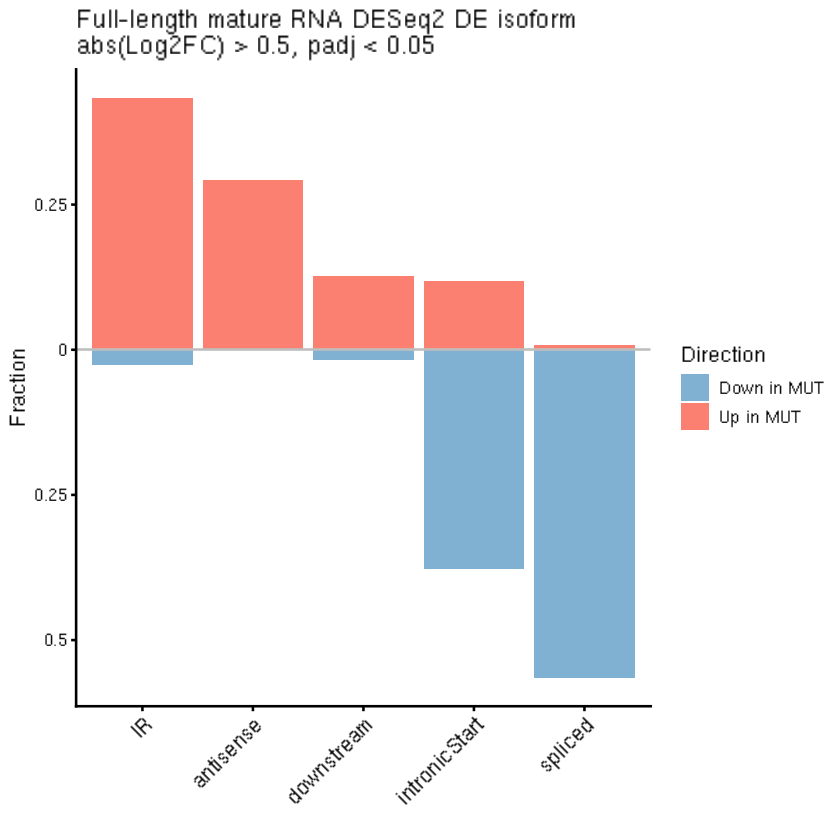

In [99]:
df<- de_df %>%
    count(labels, name = 'total_per_label') %>%
    left_join(count(de_df, labels, feature_id, name = 'feature_per_label')) %>% 
    mutate(frac = feature_per_label/total_per_label) %>% 
    mutate(frac = ifelse(labels == "Down in MUT", -frac, frac)) %>% 
    filter(labels != "Not sig")

order = df %>% arrange(-frac) %>% pull(feature_id) %>% unique()

df$feature_id<- factor(df$feature_id, levels = order)


df %>% filter(!feature_id %in% c("firstExon", "intronic", "intronicEnd")) %>% 
    ggplot(aes(x = feature_id, y = frac, fill = labels)) +
    geom_col() +
    scale_fill_manual(values = c("Down in MUT" = "#80b1d3", "Up in MUT" = "#fb8072")) +
    scale_y_continuous(labels = function(x) abs(x)) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 12)) +
    geom_hline(yintercept = 0, color = "Gray") +
    labs(x = "", y = "Fraction", fill = "Direction",
         title ="Full-length mature RNA DESeq2 DE isoform\nabs(Log2FC) > 0.5, padj < 0.05")

ggsave('../figures/Figure4_mature_rna_isoform_DE_fraction.pdf', width = 5, height = 3.5)

In [108]:
df<- read.table(file = '../data/13_mature_rna_splicing_DE_fraction_by_expr.tsv', sep = '\t', header = T)

df$class<- factor(df$class, levels = c('low', 'medium', 'high'))

mcolors <- c("#92c5de", "#f4a582", "#ca0020")
names(mcolors)<- c("low", "medium", "high")

p1<- df %>% filter(feature_id == "intronicEnd", labels == "Up in MUT") %>% 
    select(class, p ) %>% 
    complete(class, fill = list(p = 0)) %>% 
    ggplot(aes(x = class, y = p, fill = class)) +
    geom_bar(stat = "identity") +
    scale_fill_manual(values = mcolors) +
    labs(x = "", y = "Fraction", title = "Mature RNA") +
    ylim(0, 0.1) + 
    theme(legend.position = "none",     
          axis.title.x = element_blank(), 
          axis.text.x = element_blank(),
          axis.ticks.x = element_blank())

df<- read.table(file = '../data/13_nascent_rna_splicing_DE_fraction_by_expr.tsv', sep = '\t', header = T)

df$class<- factor(df$class, levels = c('low', 'medium', 'high'))

mcolors <- c("#92c5de", "#f4a582", "#ca0020")
names(mcolors)<- c("low", "medium", "high")

p2<- df %>% filter(feature_id == "intronicEnd", labels == "Up in MUT") %>% 
    select(class, p ) %>% 
    complete(class, fill = list(p = 0)) %>% 
    ggplot(aes(x = class, y = p, fill = class)) +
    geom_bar(stat = "identity") +
    scale_fill_manual(values = mcolors) +
    labs(x = "", y = "Fraction", title = "Nascent RNA") +
    ylim(0, 0.1) +
    theme(
      axis.title.x = element_blank(), 
      axis.text.x = element_blank(),
      axis.ticks.x = element_blank())


p1<- wrap_plots(c(p1, p2), ncol = 2)

p1<- p1 + plot_annotation(
  title = 'Up-regulated intronicEnd isoforms'
)

ggsave("../figures/Figure4_up_regulated_intronicEnd_fraction.pdf", p1, width = 4, height = 3)

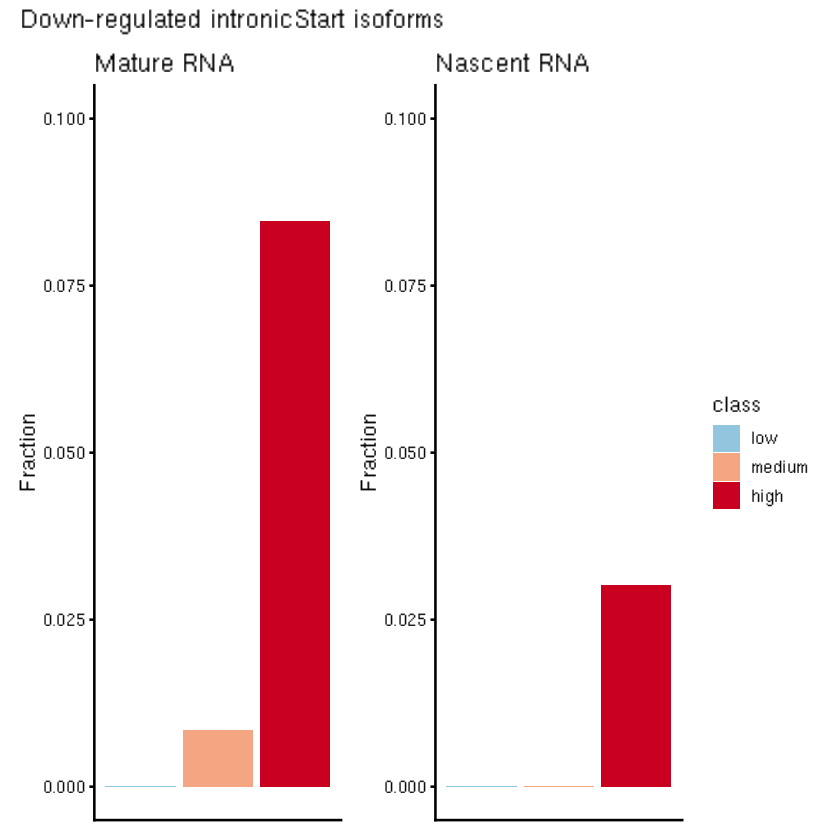

In [110]:
df<- read.table(file = '../data/13_mature_rna_splicing_DE_fraction_by_expr.tsv', sep = '\t', header = T)

df$class<- factor(df$class, levels = c('low', 'medium', 'high'))

mcolors <- c("#92c5de", "#f4a582", "#ca0020")
names(mcolors)<- c("low", "medium", "high")

p1<- df %>% filter(feature_id == "intronicStart", labels == "Down in MUT") %>% 
    select(class, p ) %>% 
    complete(class, fill = list(p = 0)) %>% 
    ggplot(aes(x = class, y = p, fill = class)) +
    geom_bar(stat = "identity") +
    scale_fill_manual(values = mcolors) +
    labs(x = "", y = "Fraction", title = "Mature RNA") +
    ylim(0, 0.1) + 
    theme(legend.position = "none",     
          axis.title.x = element_blank(), 
          axis.text.x = element_blank(),
          axis.ticks.x = element_blank())

df<- read.table(file = '../data/13_nascent_rna_splicing_DE_fraction_by_expr.tsv', sep = '\t', header = T)

df$class<- factor(df$class, levels = c('low', 'medium', 'high'))

mcolors <- c("#92c5de", "#f4a582", "#ca0020")
names(mcolors)<- c("low", "medium", "high")

p2<- df %>% filter(feature_id == "intronicStart", labels == "Down in MUT") %>% 
    select(class, p ) %>% 
    complete(class, fill = list(p = 0)) %>% 
    ggplot(aes(x = class, y = p, fill = class)) +
    geom_bar(stat = "identity") +
    scale_fill_manual(values = mcolors) +
    labs(x = "", y = "Fraction", title = "Nascent RNA") +
    ylim(0, 0.1) +
    theme(
      axis.title.x = element_blank(), 
      axis.text.x = element_blank(),
      axis.ticks.x = element_blank())


p1<- wrap_plots(c(p1, p2), ncol = 2)

p1<- p1 + plot_annotation(
  title = 'Down-regulated intronicStart isoforms'
)
p1
ggsave("../figures/Figure4_up_regulated_intronicStart_fraction.pdf", p1, width = 4, height = 3)